<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
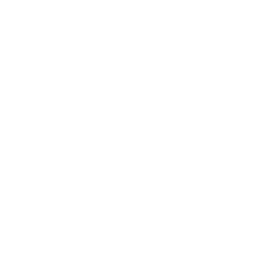
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ανάλυση Προτύπων Ψηφοφορίας Εκλογικών Τμημάτων</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Κυβέρνηση / Εκλογική Στατιστική &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για Στελέχη

Αυτή η ανάλυση εξετάζει αν η πολιτική κομματική προτίμηση διαφέρει συστηματικά ανά τύπο εκλογικού
τμήματος (αστικό, προαστιακό, αγροτικό) σε ένα προσομοιωμένο σύνολο δεδομένων εκλογών κομητείας
100 τμημάτων. Επειδή αρκετά κελιά κόμματος ανά τύπο είναι αραιά — τα μικρότερα κελιά πίνακα
συνάφειας περιέχουν μόλις ένα ή δύο τμήματα, με αναμενόμενες συχνότητες κάτω από το πέντε — ο
συνολικός έλεγχος χι-τετράγωνο Pearson γενικής συνάφειας έχει ανεπαρκή ισχύ και δεν είναι
αξιόπιστος εδώ. Γι' αυτό τον συμπληρώνουμε με τη **δοκιμασία τάσης Cochran-Armitage**, μια
εστιασμένη δοκιμασία ενός βαθμού ελευθερίας που αξιοποιεί τη φυσική διάταξη αστικό-προς-αγροτικό
και θέτει ένα πιο ακριβές ερώτημα: μήπως η υποστήριξη του Κόμματος Α μειώνεται μονοτονικά κατά
μήκος αυτής της διαβάθμισης; Η δοκιμασία τάσης αναφέρει μια ακριβή τιμή p, η οποία είναι η
κατάλληλη συμπερασματολογία όταν τα μεγέθη κελιών είναι μικρά. Η αντίθεση μεταξύ των δύο
δοκιμασιών είναι το αναλυτικό σημείο αυτού του παραδείγματος: μια γενική δοκιμασία συνάφειας
μπορεί να χάσει ένα πραγματικό κατευθυντικό πρότυπο που μια διατεταγμένη δοκιμασία τάσης
ανιχνεύει.


## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Εγγραφές σε επίπεδο εκλογικού τμήματος, μία γραμμή ανά τμήμα, με τύπο τμήματος, κομητεία, και το κόμμα πλειοψηφίας | 100 |

Το περιβάλλον εκτελείται σε λειτουργία χωρίς άδεια χρήσης, η οποία περιορίζει την έξοδο σε 100
παρατηρήσεις· η ανάλυση έχει σχεδιαστεί γύρω από αυτό το δείγμα σε επίπεδο εκλογικού τμήματος
ώστε τα κελιά πίνακα συνάφειας να είναι πραγματικά μικρά και η ακριβής δοκιμασία τάσης να είναι
το φυσικό εργαλείο.


---


In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικών δεδομένων ψηφοφορίας σε επίπεδο
   εκλογικού τμήματος
   Μικρά μεγέθη κελιών σε αγροτικά τμήματα για να καταδειχθεί
   η ανάγκη για ακριβείς (exact) δοκιμασίες
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.precinct_votes;
    CALL streaminit(42);
    LENGTH precinct_type $30 party $30 county_name $30;
    ΕΠΑΝΑΛΗΨΗ precinct_seq = 1 ΕΩΣ 500;
        precinct_id = cat('PCT-', PUT(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        ΕΑΝ county_idx = 1 ΤΟΤΕ county_name = 'Τζέφερσον';
        ΑΛΛΙΩΣ ΕΑΝ county_idx = 2 ΤΟΤΕ county_name = 'Χάμιλτον';
        ΑΛΛΙΩΣ ΕΑΝ county_idx = 3 ΤΟΤΕ county_name = 'Μάντισον';
        ΑΛΛΙΩΣ ΕΑΝ county_idx = 4 ΤΟΤΕ county_name = 'Άνταμς';
        ΑΛΛΙΩΣ county_name = 'Μονρόε';
        /* Ανάθεση τύπου εκλογικού τμήματος με στάθμιση */
        type_prob = rand('uniform');
        ΕΑΝ type_prob < 0.30 ΤΟΤΕ precinct_type = 'Αστική';
        ΑΛΛΙΩΣ ΕΑΝ type_prob < 0.65 ΤΟΤΕ precinct_type = 'Προαστιακή';
        ΑΛΛΙΩΣ precinct_type = 'Αγροτική';
        /* Ανάθεση κόμματος με κατανομή που εξαρτάται από τον τύπο */
        party_prob = rand('uniform');
        ΕΑΝ precinct_type = 'Αστική' ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            ΕΑΝ party_prob < 0.55 ΤΟΤΕ party = 'Κόμμα Α';
            ΑΛΛΙΩΣ ΕΑΝ party_prob < 0.80 ΤΟΤΕ party = 'Κόμμα Β';
            ΑΛΛΙΩΣ ΕΑΝ party_prob < 0.92 ΤΟΤΕ party = 'Κόμμα Γ';
            ΑΛΛΙΩΣ party = 'Ανεξάρτητοι';
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΑΝ precinct_type = 'Προαστιακή' ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            ΕΑΝ party_prob < 0.40 ΤΟΤΕ party = 'Κόμμα Α';
            ΑΛΛΙΩΣ ΕΑΝ party_prob < 0.75 ΤΟΤΕ party = 'Κόμμα Β';
            ΑΛΛΙΩΣ ΕΑΝ party_prob < 0.88 ΤΟΤΕ party = 'Κόμμα Γ';
            ΑΛΛΙΩΣ party = 'Ανεξάρτητοι';
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ; /* Αγροτική - μικρότερα κελιά για μειοψηφικά κόμματα */
            ΕΑΝ party_prob < 0.25 ΤΟΤΕ party = 'Κόμμα Α';
            ΑΛΛΙΩΣ ΕΑΝ party_prob < 0.70 ΤΟΤΕ party = 'Κόμμα Β';
            ΑΛΛΙΩΣ ΕΑΝ party_prob < 0.85 ΤΟΤΕ party = 'Κόμμα Γ';
            ΑΛΛΙΩΣ party = 'Ανεξάρτητοι';
        ΤΕΛΟΣ;
        /* Ο αριθμός ψήφων ποικίλλει ανά τύπο εκλογικού τμήματος */
        ΕΑΝ precinct_type = 'Αστική' ΤΟΤΕ
            vote_count = int(rand('normal', 120, 40));
        ΑΛΛΙΩΣ ΕΑΝ precinct_type = 'Προαστιακή' ΤΟΤΕ
            vote_count = int(rand('normal', 80, 25));
        ΑΛΛΙΩΣ
            vote_count = int(rand('normal', 25, 12));
        ΕΑΝ vote_count < 1 ΤΟΤΕ vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        ΕΤΙΚΕΤΑ precinct_type='Τύπος Εκλογικού Τμήματος'
              party='Κόμμα'
              county_name='Κομητεία'
              vote_count='Αριθμός Ψήφων'
              registered_voters='Εγγεγραμμένοι Ψηφοφόροι'
              turnout_pct='Προσέλευση (%)'
              election_year='Έτος Εκλογών';
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ precinct_seq county_idx type_prob party_prob;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.16 seconds
  cpu   0.16 seconds


---


                                                   The FREQ Procedure

Τύπος Εκλογικού Τμήματος                          Frequency    Percent
-----------------------------------------------------------------------
Αγροτική                                                 34     34.00
Αστική                                                   29     29.00
Προαστιακή                                               37     37.00

Κόμμα                     Frequency    Percent
-----------------------------------------------
Ανεξάρτητοι                       9      9.00
Κόμμα Α                          45     45.00
Κόμμα Β                          34     34.00
Κόμμα Γ                          12     12.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


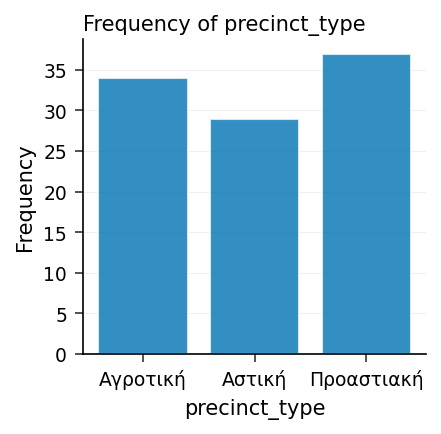

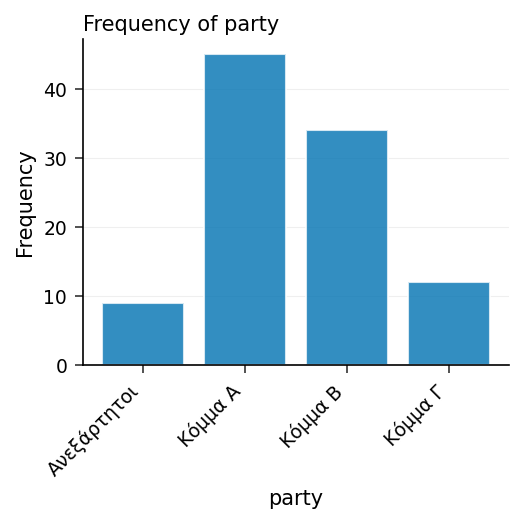

In [2]:
/* --------------------------------------------------------
   Βασική κατανομή τύπου εκλογικού τμήματος και κόμματος
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
ΕΚΤΕΛΕΣΗ;


---



NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


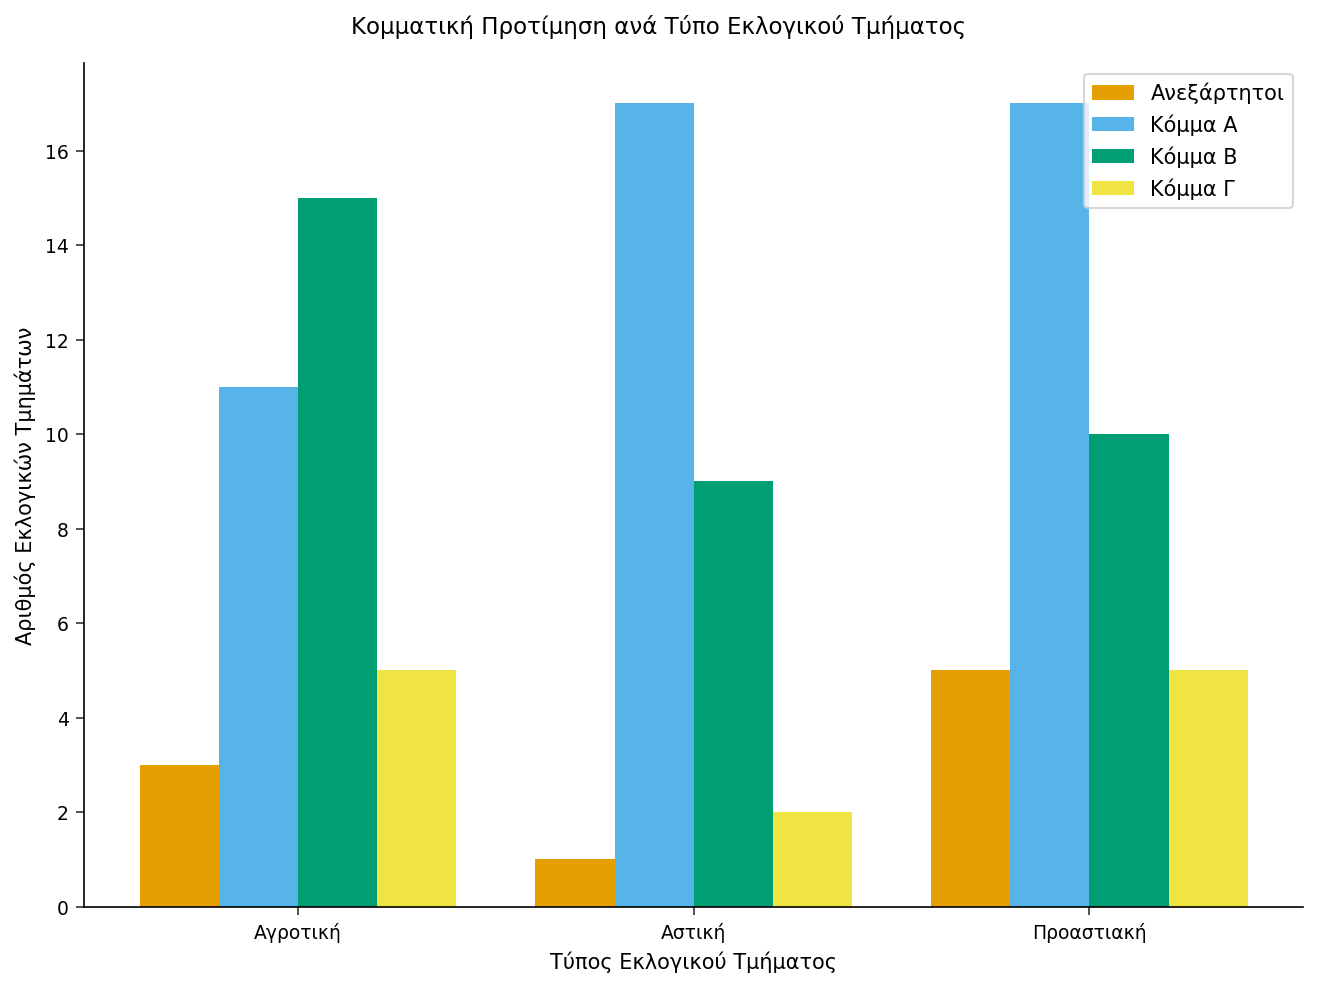

In [3]:
/* --------------------------------------------------------
   Κομματική προτίμηση ανά τύπο εκλογικού τμήματος (μετρήσεις τμημάτων)
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=ΣΥΧΝΟΤΗΤΕΣ;
    XAXIS ΕΤΙΚΕΤΑ='Τύπος Εκλογικού Τμήματος';
    YAXIS ΕΤΙΚΕΤΑ='Αριθμός Εκλογικών Τμημάτων';
    TITLE 'Κομματική Προτίμηση ανά Τύπο Εκλογικού Τμήματος';
ΕΚΤΕΛΕΣΗ;


---


                       Τύπος Εκλογικού Τμήματος ανά Κόμμα: Διασταύρωση με Αναμενόμενες Συχνότητες                       

                                                   The FREQ Procedure

Table of Τύπος Εκλογικού Τμήματος by Κόμμα

Τύπος Εκλογικού Τμήματος                       |           Ανεξάρτητοι |               Κόμμα Α |               Κόμμα Β |               Κόμμα Γ |                  Total
-----------------------------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
Αγροτική                                       |                     3 |                    11 |                    15 |                     5 |                     34
                                               |                  3.00 |                 11.00 |                 15.00 |                  5.00 |                  34.00
                                               |                  3.06 |                 15


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


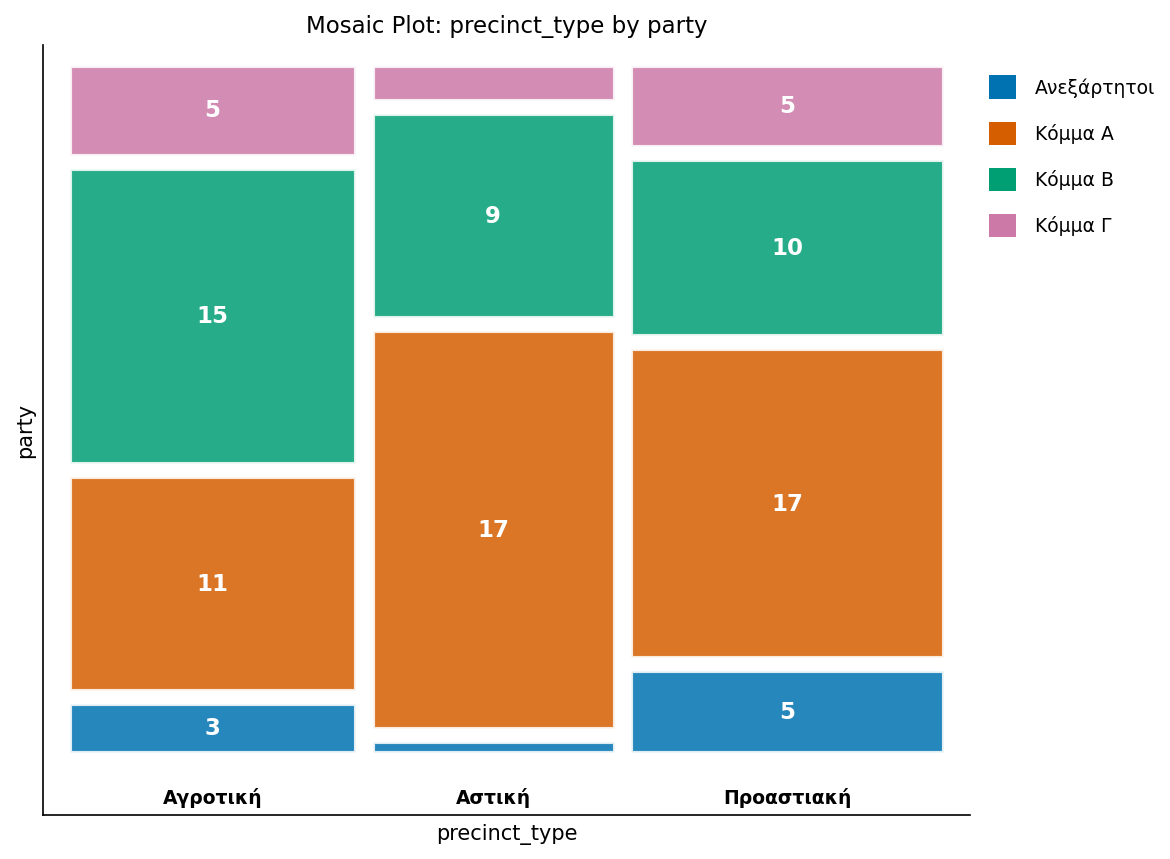

In [4]:
/* --------------------------------------------------------
   Διασταύρωση τύπου εκλογικού τμήματος x κόμματος.
   Ζητούνται ΑΝΑΜΕΝΟΜΕΝΕΣ συχνότητες ώστε να είναι ορατά τα αραιά
   κελιά, καθώς και ο ασυμπτωτικός έλεγχος χι-τετράγωνο Pearson
   γενικής συνάφειας. Σημειώστε τις μικρές αναμενόμενες συχνότητες
   στις στήλες ΑΝΕΞΑΡΤΗΤΟΙ και ΚΟΜΜΑ Γ -- η ένδειξη ότι μια
   διατεταγμένη, ακριβής δοκιμασία τάσης είναι το καλύτερο
   εργαλείο συμπερασματολογίας.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    TITLE 'Τύπος Εκλογικού Τμήματος ανά Κόμμα: Διασταύρωση με Αναμενόμενες Συχνότητες';
ΕΚΤΕΛΕΣΗ;


                  Δοκιμασία Τάσης Cochran-Armitage: Υποστήριξη Κόμματος Α στο Φάσμα Εκλογικών Τμημάτων                  

                                                   The FREQ Procedure

Table of Τακτική Βαθμολογία Τύπου by Σημαία Κόμματος Α

Τακτική Βαθμολογία Τύπου                       |         0 |         1 |      Total
-----------------------------------------------+-----------+-----------+-----------
1                                              |        12 |        17 |         29
                                               |     12.00 |     17.00 |      29.00
                                               |     41.38 |     58.62 |     100.00
                                               |     21.82 |     37.78 |      29.00
-----------------------------------------------+-----------+-----------+-----------
2                                              |        20 |        17 |         37
                                               |     20.00 |     17.00 |      3


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


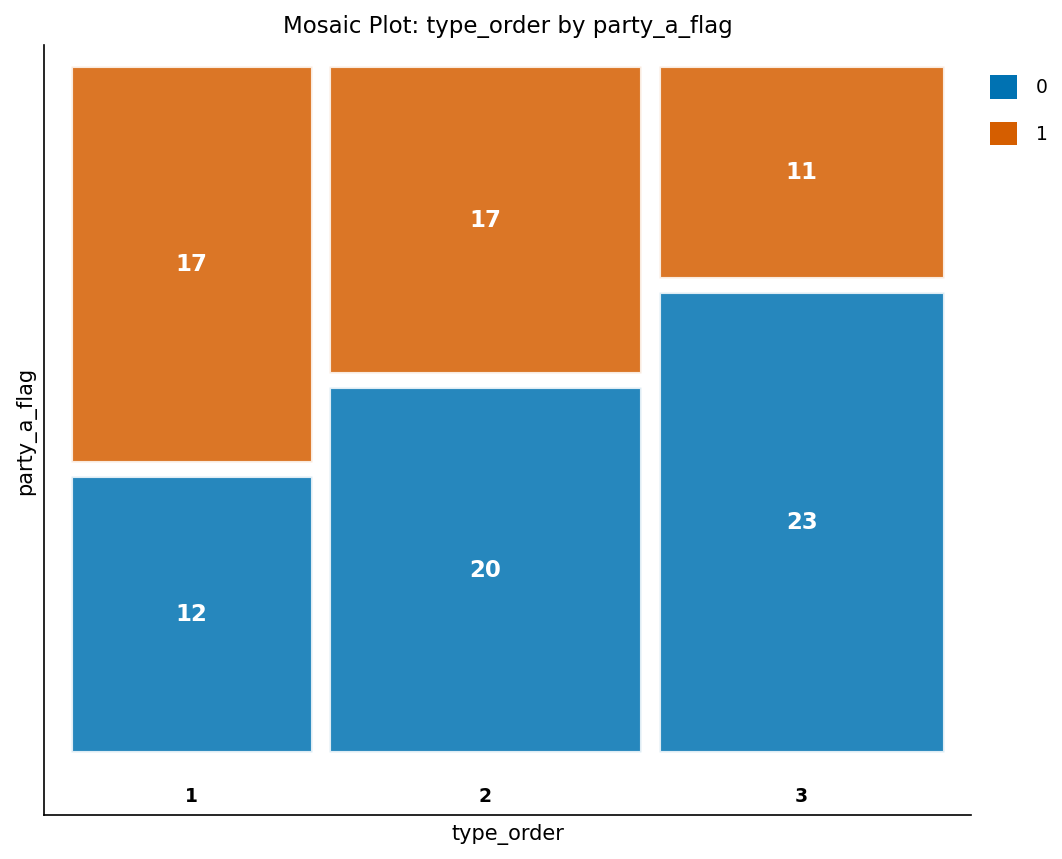

In [5]:
/* --------------------------------------------------------
   Δοκιμασία τάσης Cochran-Armitage. Ο τύπος εκλογικού τμήματος
   αναδιακωδικοποιείται σε τακτική βαθμολογία (1=Αστική,
   2=Προαστιακή, 3=Αγροτική) και ελέγχεται αν η υποστήριξη του
   Κόμματος Α παρουσιάζει μονοτονική τάση κατά μήκος του φάσματος.
   EXACT TREND ζητά την ακριβή τιμή p, κατάλληλη δεδομένων των
   μικρών μεγεθών κελιών.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.precinct_ordinal;
    ΟΡΙΣΜΟΣ work.precinct_votes;
    /* Τακτική κωδικοποίηση: 1=Αστική, 2=Προαστιακή, 3=Αγροτική */
    ΕΑΝ precinct_type = 'Αστική' ΤΟΤΕ type_order = 1;
    ΑΛΛΙΩΣ ΕΑΝ precinct_type = 'Προαστιακή' ΤΟΤΕ type_order = 2;
    ΑΛΛΙΩΣ type_order = 3;
    /* Δυαδική έκβαση: Κόμμα Α έναντι όλων των άλλων προτιμήσεων */
    party_a_flag = (party = 'Κόμμα Α');
    ΕΤΙΚΕΤΑ type_order='Τακτική Βαθμολογία Τύπου'
          party_a_flag='Σημαία Κόμματος Α';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    TITLE 'Δοκιμασία Τάσης Cochran-Armitage: Υποστήριξη Κόμματος Α στο Φάσμα Εκλογικών Τμημάτων';
ΕΚΤΕΛΕΣΗ;


                                     Κατανομή Τύπου Εκλογικού Τμήματος ανά Κομητεία                                     

                                                   The FREQ Procedure

Table of Κομητεία by Τύπος Εκλογικού Τμήματος

Κομητεία           |            Αγροτική |              Αστική |          Προαστιακή |                Total
-------------------+---------------------+---------------------+---------------------+---------------------
Άνταμς             |                   5 |                   4 |                  10 |                   19
                   |                5.00 |                4.00 |               10.00 |                19.00
                   |               26.32 |               21.05 |               52.63 |               100.00
                   |               14.71 |               13.79 |               27.03 |                19.00
-------------------+---------------------+---------------------+---------------------+---------------------
Μάντ


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


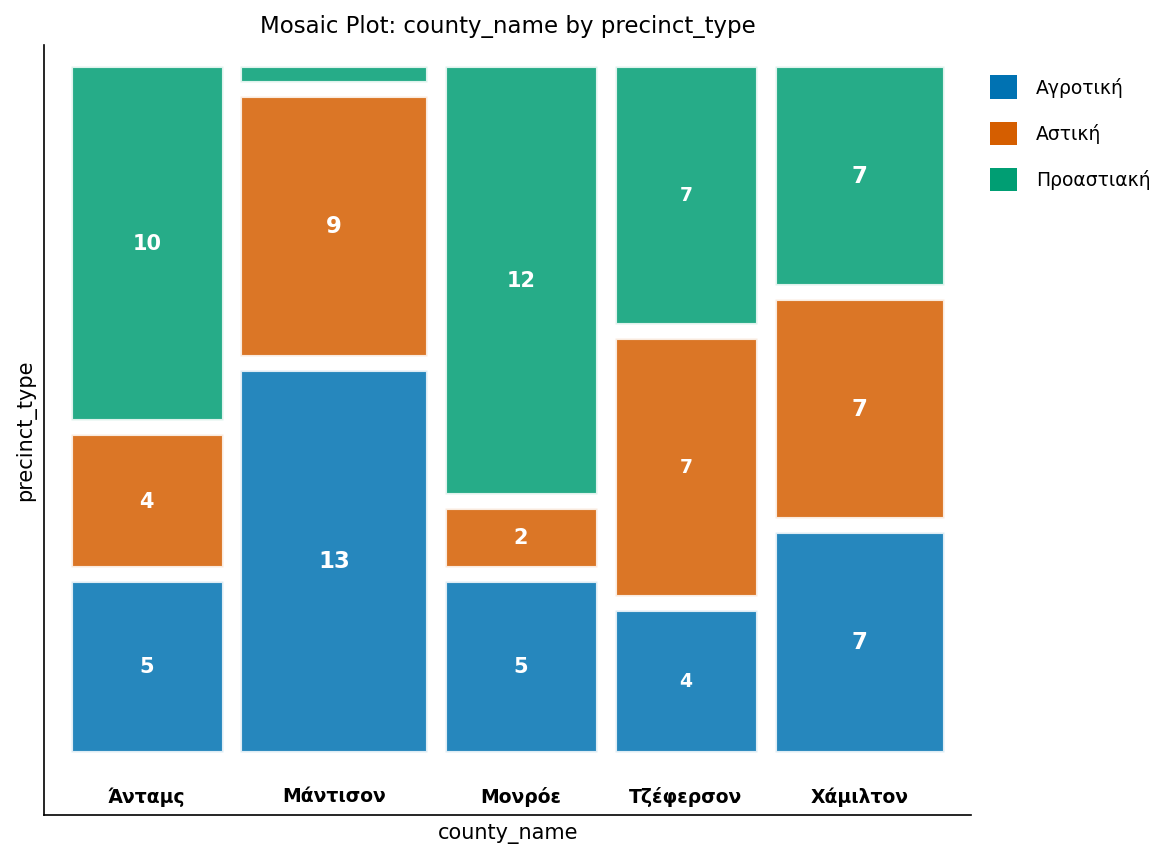

In [6]:
/* --------------------------------------------------------
   Άποψη σε επίπεδο κομητείας: πώς ποικίλλει το μείγμα
   αστικών/προαστιακών/αγροτικών τμημάτων ανά τις πέντε κομητείες.
   Αυτό πλαισιώνει το αποτέλεσμα της τάσης -- η διαβάθμιση των
   εκλογικών τμημάτων υπάρχει σε κάθε κομητεία, αλλά η σύνθεσή
   της διαφέρει.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    TITLE 'Κατανομή Τύπου Εκλογικού Τμήματος ανά Κομητεία';
ΕΚΤΕΛΕΣΗ;


---


### Ερμηνεία

Στα 100 εκλογικά τμήματα, το Κόμμα Α κατέχει τη σχετική πλειοψηφία συνολικά (45 τμήματα),
ακολουθούμενο από το Κόμμα Β (34), το Κόμμα Γ (12), και τους Ανεξάρτητους (9). Η διασταύρωση
δείχνει ότι το μερίδιο του Κόμματος Α ακολουθεί μια σαφή διαβάθμιση από την αστική προς την
αγροτική περιοχή: αντιπροσωπεύει το 58,6% των αστικών τμημάτων, το 46,0% των προαστιακών
τμημάτων, και το 32,4% των αγροτικών τμημάτων, ενώ το Κόμμα Β κινείται προς την αντίθετη
κατεύθυνση, αυξανόμενο από 31,0% στα αστικά σε 44,1% στα αγροτικά.

Ο συνολικός έλεγχος χι-τετράγωνο Pearson γενικής συνάφειας **δεν** είναι στατιστικά σημαντικός
(χι-τετράγωνο = 6,78, 6 β.ε., p = 0,3418· Cramer's V = 0,18). Το αποτέλεσμα αυτό είναι επίσης
εύθραυστο: η προβολή αναμενόμενων συχνοτήτων αποκαλύπτει αρκετά κελιά κάτω από το πέντε — για
παράδειγμα, η στήλη των Ανεξάρτητων έχει αναμενόμενες συχνότητες 3,06, 3,33, και 2,61, και οι
αστικοί Ανεξάρτητοι αριθμούν μόλις ένα τμήμα — οπότε η προσέγγιση χι-τετράγωνο μεγάλου δείγματος
δεν είναι αξιόπιστη εδώ.

Η δοκιμασία τάσης Cochran-Armitage οξύνει το ερώτημα χρησιμοποιώντας την τακτική βαθμολόγηση
αστική-προαστιακή-αγροτική. Ανιχνεύει τη μονοτονική πτώση στην υποστήριξη του Κόμματος Α που
διαφεύγει από τον συνολικό έλεγχο: χι-τετράγωνο τάσης = 4,38 με ασυμπτωτικό Pr > ChiSq = 0,0363
και **ακριβές Pr >= |Z| = 0,0431**, σημαντικό στο επίπεδο 0,05. Αυτό είναι το αναλυτικό όφελος —
μια εστιασμένη, ακριβής δοκιμασία ενός βαθμού ελευθερίας ανακτά ένα πραγματικό κατευθυντικό
σήμα που ο γενικός έλεγχος συνάφειας 6 βαθμών ελευθερίας, εξασθενημένος από τα αραιά κελιά, δεν
ανακτά.

Η άποψη σε επίπεδο κομητείας επιβεβαιώνει ότι ο διαχωρισμός αστικό/προαστιακό/αγροτικό υπάρχει
σε όλες τις πέντε κομητείες, αν και το μείγμα διαφέρει: το Μάντισον είναι το πιο αγροτικό (13 από
23 τμήματα αγροτικά) ενώ το Μονρόε είναι το πιο προαστιακό (12 από 19). Για την αξιολόγηση
επίπτωσης επαναχάραξης ορίων, το συμπέρασμα είναι ότι αλλαγές ορίων που μετακινούν τμήματα κατά
μήκος του άξονα αστικό-αγροτικό θα μετέβαλλαν μετρήσιμα την κομματική σύνθεση, και ότι αυτή η
γεωγραφική τάση τεκμηριώνεται καλύτερα από την ακριβή δοκιμασία τάσης παρά από τον συνολικό
έλεγχο χι-τετράγωνο.


---


                                     Κατανομή Τύπου Εκλογικού Τμήματος ανά Κομητεία                                     

                                                   The FREQ Procedure

Table of Τύπος Εκλογικού Τμήματος by Κόμμα

Τύπος Εκλογικού Τμήματος                       |           Ανεξάρτητοι |               Κόμμα Α |               Κόμμα Β |               Κόμμα Γ |                  Total
-----------------------------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
Αγροτική                                       |                     3 |                    11 |                    15 |                     5 |                     34
                                               |                  3.00 |                 11.00 |                 15.00 |                  5.00 |                  34.00
                                               |                  8.82 |                 32


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


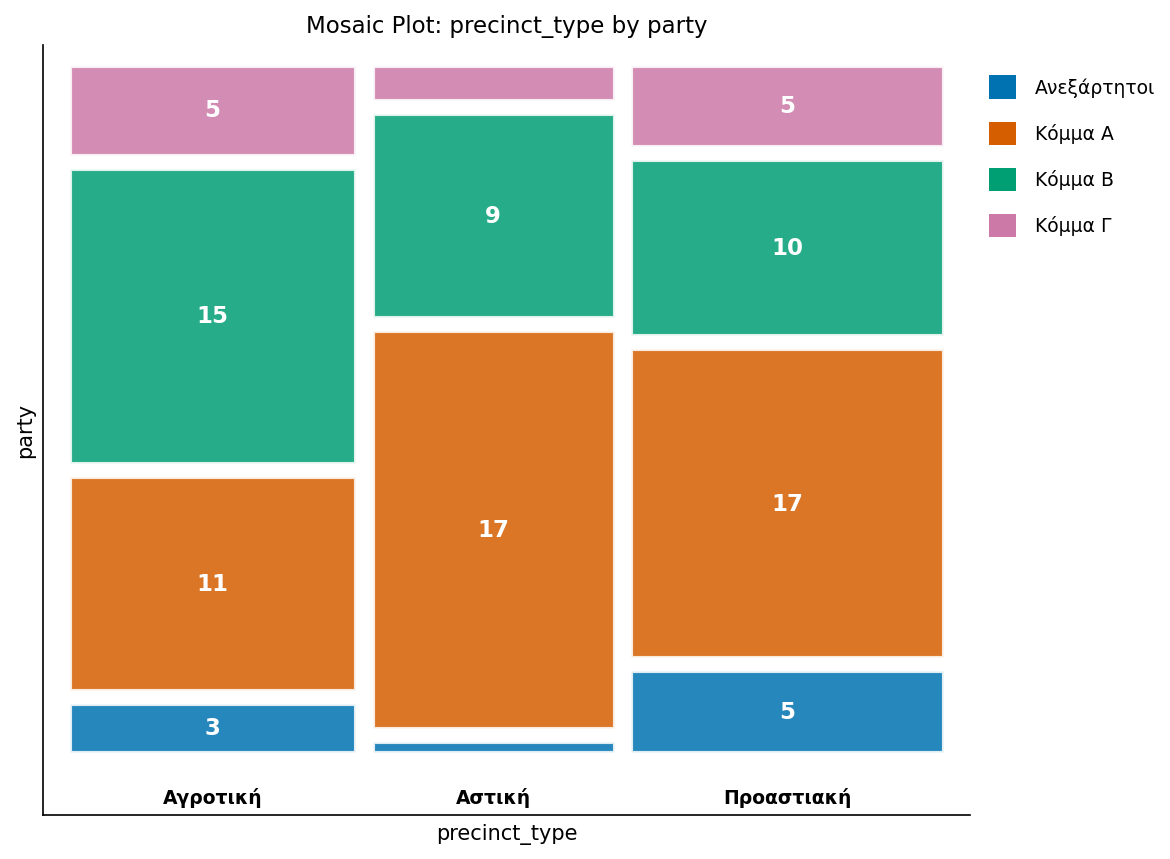

In [7]:
/* --------------------------------------------------------
   Εξαγωγή της σύνοψης τύπου εκλογικού τμήματος x κόμμα για
   κατάντη αξιολόγηση επίπτωσης επαναχάραξης ορίων.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>